In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

In [2]:
import tensorflow as tf
import tensorflow_hub as hub

model = hub.load(
    "https://tfhub.dev/google/universal-sentence-encoder/4"
)

print("model loaded")

model loaded


# Simple example

## Some sentences

In [3]:
corpus = [
    # --- Cluster 1: Finance / markets ---
    "The stock market dropped after the earnings report.",
    "Investors reacted to weak earnings and the price fell.",
    "The company’s quarterly results pushed shares lower.",

    # --- Cluster 2: Cooking / food ---
    "I cooked garlic butter shrimp for dinner.",
    "Tonight I made pasta with garlic and shrimp.",
    "I tried a new shrimp recipe with butter and herbs.",

    # --- Cluster 3: Dogs / pets ---
    "My dog chased a tennis ball across the yard.",
    "The puppy ran after the ball and then took a nap.",
    "My dog played fetch and fell asleep on the couch.",

    # --- Cluster 4: PCA / linear algebra ---
    "I used PCA to reduce the dataset to two dimensions.",
    "Principal component analysis finds directions of maximum variance.",
    "PCA projects high-dimensional data onto a smaller set of components.",

    # --- Oddball (should be less similar to everything) ---
    "A thunderstorm rolled in and lightning lit up the sky."
]

## Embed corpus

In [4]:
embedded_corpus = model(corpus).numpy()

print("Embedding dimension:", embedded_corpus[0].shape[0])
print()
print("Example embedding:\n", embedded_corpus[0])

Embedding dimension: 512

Example embedding:
 [ 0.00366393  0.01932622 -0.01990204 -0.0128672  -0.04027443  0.06047326
  0.01803028  0.03468379  0.05150457 -0.00178228 -0.04374281  0.01411863
 -0.05610992 -0.0456266  -0.05179856 -0.02274059 -0.04200733 -0.08147715
 -0.04079098  0.03628226 -0.06786323 -0.0253686  -0.02467962 -0.01301877
 -0.04454515 -0.03205134 -0.0372079   0.06172546 -0.01698848  0.01800817
 -0.01473716 -0.00416317  0.07456546 -0.01597369  0.00319721 -0.07191312
 -0.06910941 -0.02705673  0.01873554 -0.07341704  0.03227402  0.00993449
 -0.01096462 -0.02169034  0.03651605  0.0675799   0.0190574  -0.01287963
 -0.05791793 -0.03300809 -0.03944581 -0.00554399  0.0342464   0.07598118
 -0.04933649  0.06470407  0.0400224   0.05972758  0.05695948 -0.0245485
 -0.02451959  0.02108239  0.02424715 -0.00735915  0.01524035 -0.05241806
  0.03924033 -0.01352837  0.01717896  0.0197605  -0.01645025 -0.05547129
 -0.05684749  0.03588955  0.0653378  -0.07345411  0.02842343  0.08524955
  0.01

## Plot cosine similarity

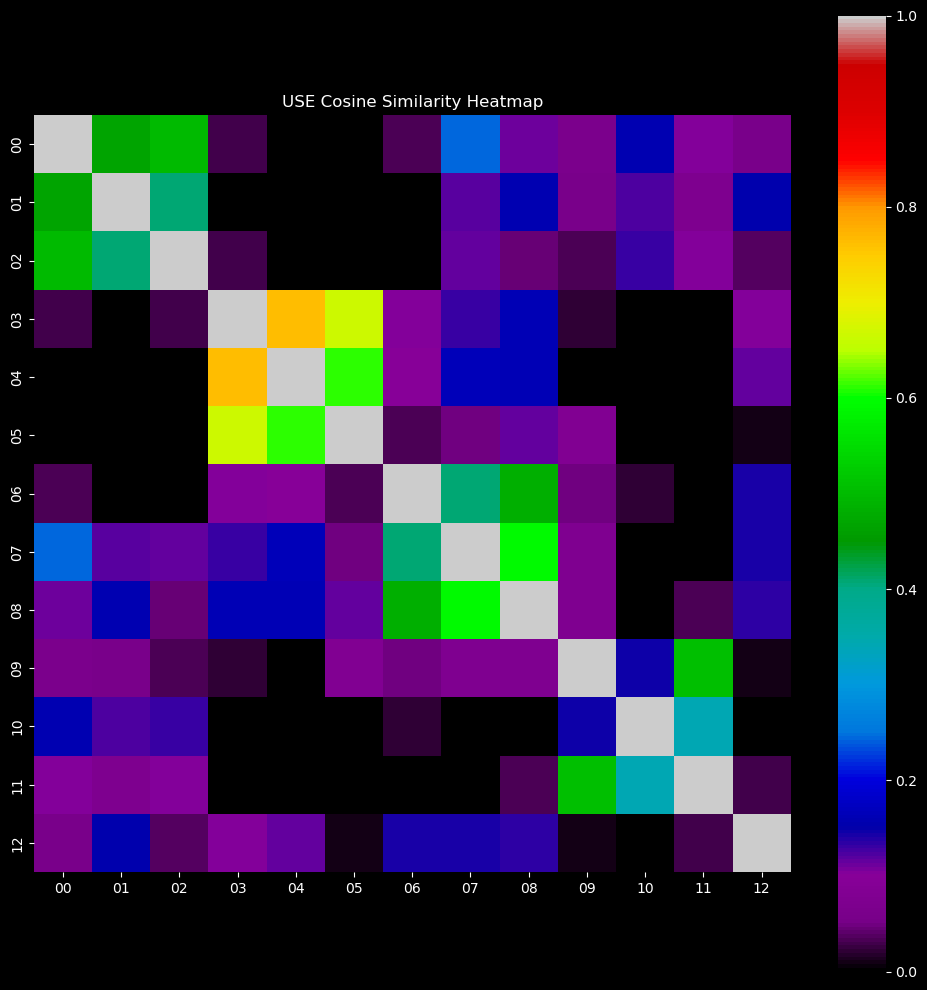

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(embedded_corpus)

# Plot heatmap
size = 10
fig, ax = plt.subplots(1, 1, figsize=(size, size))

sns.heatmap(
    cosine_sim,
    square=True,
    cbar=True,
    vmin=0, vmax=1,
    cmap="nipy_spectral",
    xticklabels=[f"{i:02d}" for i in range(len(corpus))],
    yticklabels=[f"{i:02d}" for i in range(len(corpus))]
)

ax.set_title("USE Cosine Similarity Heatmap")
plt.tight_layout()
plt.show()

# Bible Example

## Load text

In [6]:
data_folder = "C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/Text Processing/"
with open(data_folder + "bible.txt", encoding="utf-8") as f:
    text_raw = f.read()

print(text_raw[:500])

Genesis 1:1	In the beginning God created the heaven and the earth.
Genesis 1:2	And the earth was without form, and void; and darkness [was] upon the face of the deep. And the Spirit of God moved upon the face of the waters.
Genesis 1:3	And God said, Let there be light: and there was light.
Genesis 1:4	And God saw the light, that [it was] good: and God divided the light from the darkness.
Genesis 1:5	And God called the light Day, and the darkness he called Night. And the evening and the morning w


## Clean text into single string

In [8]:
import re

n_verses = 500

text = ''

for line in text_raw.split('\n')[:n_verses]:    
    verse_text = line.split("\t")[1].strip().lower()
    text += verse_text + " "

text = text.strip().lower()
text = re.sub(r'\s+', ' ', text)
text = re.sub(r'[^a-z\'\s]', '', text)

text[:500]

'in the beginning god created the heaven and the earth and the earth was without form and void and darkness was upon the face of the deep and the spirit of god moved upon the face of the waters and god said let there be light and there was light and god saw the light that it was good and god divided the light from the darkness and god called the light day and the darkness he called night and the evening and the morning were the first day and god said let there be a firmament in the midst of the w'

## Chunkify text

In [9]:
seq_len = 15
stride = 1
n_samp = 100

corpus = []
words = text.split()
for i in range(n_samp):
    #corpus.append( text[i*stride:i*stride+seq_len] )
    corpus.append( " ".join(words[i*stride:i*stride+seq_len]) )
    print(corpus[-1])
# end

in the beginning god created the heaven and the earth and the earth was without
the beginning god created the heaven and the earth and the earth was without form
beginning god created the heaven and the earth and the earth was without form and
god created the heaven and the earth and the earth was without form and void
created the heaven and the earth and the earth was without form and void and
the heaven and the earth and the earth was without form and void and darkness
heaven and the earth and the earth was without form and void and darkness was
and the earth and the earth was without form and void and darkness was upon
the earth and the earth was without form and void and darkness was upon the
earth and the earth was without form and void and darkness was upon the face
and the earth was without form and void and darkness was upon the face of
the earth was without form and void and darkness was upon the face of the
earth was without form and void and darkness was upon the face of the

## Embed chunks and plot similarity

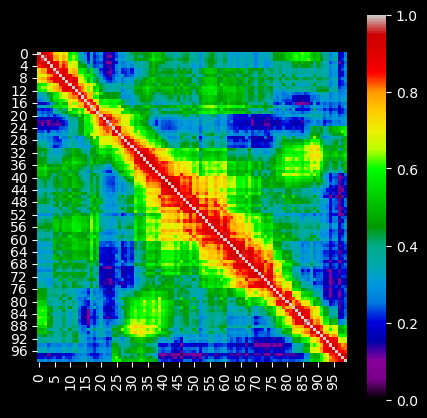

In [10]:
embedded_corpus = model(corpus).numpy()

size = 5
fig, axes = plt.subplots(1, 1, figsize=(size,size))

cosine_sim = cosine_similarity(embedded_corpus)

sns.heatmap(cosine_sim, square=True, cbar=True,
            vmin=0, vmax=1, cmap='nipy_spectral')
plt.show()